<a href="https://colab.research.google.com/github/yadavrishikesh/Masterclass-IITMandi/blob/main/Module1/assignment/Real_Time_Weather_Analytics_solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Part A: Real-Time Weather Analytics


### Q1. Data Collection

In [ ]:
!pip install requests

In [ ]:
!pip install openmeteo-requests
!pip install requests-cache retry-requests numpy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.1/165.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 669.8/669.8 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.9/247.9 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.4/393.4 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 5.1 MB/s eta 0:00:00


In [ ]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://api.open-meteo.com/v1/forecast"
params = {
        "latitude": [31.1046, 31.7183, 32.2146, 30.9045, 32.558],
        "longitude": [77.1734, 76.9315, 76.3237, 77.1066, 76.1293],
        "hourly": ["wind_speed_10m", "visibility", "cloud_cover"],
        "past_days": 31
}
responses = openmeteo.weather_api(url, params=params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation {response.Elevation()} m asl")
print(f"Timezone {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0 {response.UtcOffsetSeconds()} s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_wind_speed_10m = hourly.Variables(0).ValuesAsNumpy()
hourly_visibility = hourly.Variables(1).ValuesAsNumpy()
hourly_cloud_cover = hourly.Variables(2).ValuesAsNumpy()

hourly_data = {"date": pd.date_range(
        start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
        end = pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
        freq = pd.Timedelta(seconds = hourly.Interval()),
        inclusive = "left"
)}

hourly_data["wind_speed_10m"] = hourly_wind_speed_10m
hourly_data["visibility"] = hourly_visibility
hourly_data["cloud_cover"] = hourly_cloud_cover

hourly_dataframe = pd.DataFrame(data = hourly_data)
print(hourly_dataframe)

Coordinates 31.0°N 77.25°E
Elevation 2195.0 m asl
Timezone NoneNone
Timezone difference to GMT+0 0 s
                         date  wind_speed_10m  visibility  cloud_cover
0   2025-05-25 00:00:00+00:00        3.319036     24140.0        100.0
1   2025-05-25 01:00:00+00:00        3.415260     24140.0        100.0
2   2025-05-25 02:00:00+00:00        4.735060     24140.0        100.0
3   2025-05-25 03:00:00+00:00        5.040000     24140.0        100.0
4   2025-05-25 04:00:00+00:00        2.099143     24140.0        100.0
..                        ...             ...         ...          ...
907 2025-07-01 19:00:00+00:00        4.379589     14140.0         52.0
908 2025-07-01 20:00:00+00:00        4.024922     14340.0         46.0
909 2025-07-01 21:00:00+00:00        3.877318     14520.0         41.0
910 2025-07-01 22:00:00+00:00        4.213692     17720.0         43.0
911 2025-07-01 23:00:00+00:00        4.896529     20940.0         44.0

[912 rows x 4 columns]


### Q2. Data Wrangling & Cleaning


In [ ]:
# Rename columns for better readability
hourly_dataframe = hourly_dataframe.rename(columns={
    'date': 'timestamp',
    'wind_speed_10m': 'wind_speed',
    'visibility': 'visibility_meters',
    'cloud_cover': 'cloud_cover_percentage'
})

# Check for missing values
print("Missing values before handling:")
print(hourly_dataframe.isnull().sum())

Missing values before handling:
timestamp                 0
wind_speed                0
visibility_meters         0
cloud_cover_percentage    0
dtype: int64


In [ ]:
# Handle missing values (if any)
hourly_dataframe = hourly_dataframe.ffill()
# Example: Filling with mean (might not be suitable for time series)
# hourly_dataframe['wind_speed'] = hourly_dataframe['wind_speed'].fillna(hourly_dataframe['wind_speed'].mean())

print("\nMissing values after handling:")
print(hourly_dataframe.isnull().sum())


Missing values after handling:
timestamp                 0
wind_speed                0
visibility_meters         0
cloud_cover_percentage    0
dtype: int64


In [ ]:
# Create a datetime column (if it's not already in datetime format)
# In this case, 'timestamp' is already created as a datetime series from pd.date_range
# We can ensure it's in the correct datetime format with UTC timezone.
hourly_dataframe['timestamp'] = pd.to_datetime(hourly_dataframe['timestamp'], utc=True)

# Set the timestamp as the index for easier time-based operations
hourly_dataframe = hourly_dataframe.set_index('timestamp')

print("\nCleaned DataFrame:")
print(hourly_dataframe.head())
print("\nDataFrame Info:")
hourly_dataframe.info()


Cleaned DataFrame:
                           wind_speed  visibility_meters  \
timestamp                                                  
2025-05-25 00:00:00+00:00    3.319036            24140.0   
2025-05-25 01:00:00+00:00    3.415260            24140.0   
2025-05-25 02:00:00+00:00    4.735060            24140.0   
2025-05-25 03:00:00+00:00    5.040000            24140.0   
2025-05-25 04:00:00+00:00    2.099143            24140.0   

                           cloud_cover_percentage  
timestamp                                          
2025-05-25 00:00:00+00:00                   100.0  
2025-05-25 01:00:00+00:00                   100.0  
2025-05-25 02:00:00+00:00                   100.0  
2025-05-25 03:00:00+00:00                   100.0  
2025-05-25 04:00:00+00:00                   100.0  

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 912 entries, 2025-05-25 00:00:00+00:00 to 2025-07-01 23:00:00+00:00
Data columns (total 3 columns):
 #   Column              

### Q3. Exploratory Data Analysis

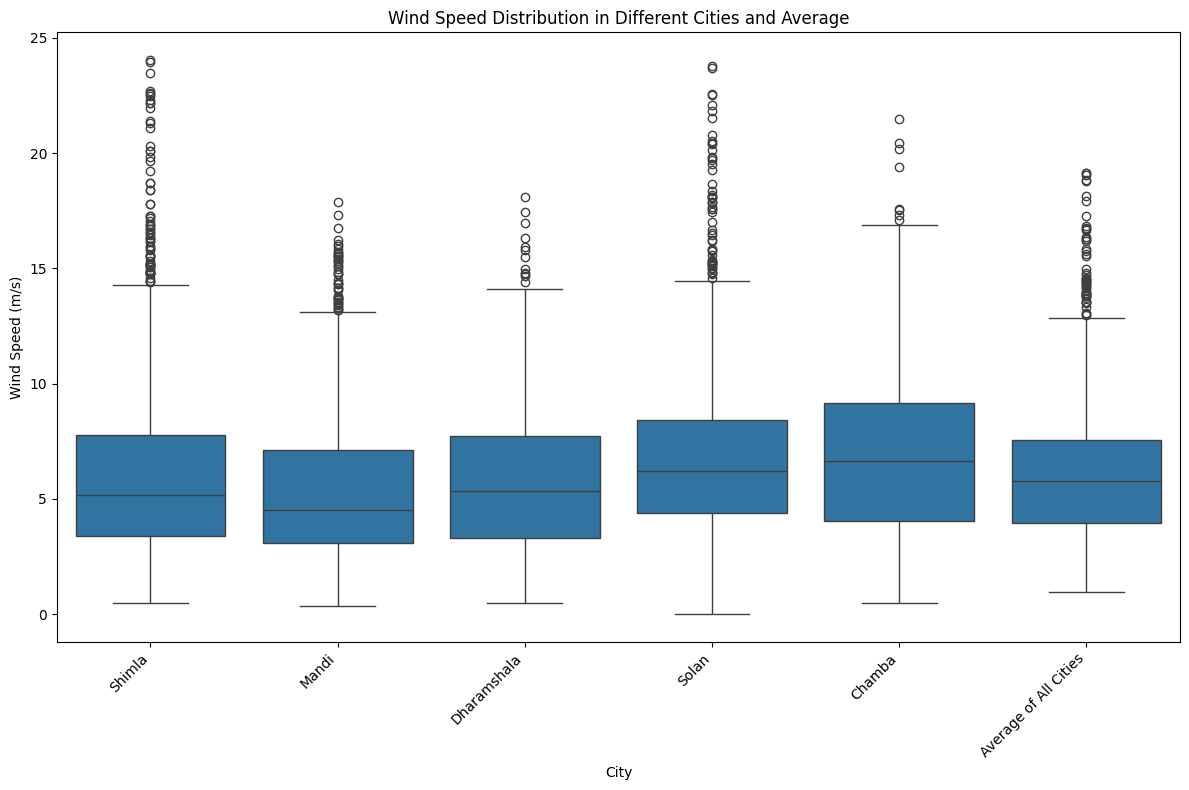

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define city names corresponding to the latitudes/longitudes
cities = ["Shimla", "Mandi", "Dharamshala", "Solan", "Chamba"]

# Create a list to store dataframes for each city
city_dfs = []

# Loop through each response (city) and process the hourly data
for i, response in enumerate(responses):
    city_name = cities[i]

    hourly = response.Hourly()
    hourly_wind_speed_10m = hourly.Variables(0).ValuesAsNumpy()

    hourly_data = {"date": pd.date_range(
            start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
            end = pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
            freq = pd.Timedelta(seconds = hourly.Interval()),
            inclusive = "left"
    )}

    hourly_data["wind_speed_10m"] = hourly_wind_speed_10m
    city_df = pd.DataFrame(data = hourly_data)

    # Rename column and add city name
    city_df = city_df.rename(columns={'wind_speed_10m': 'wind_speed'})
    city_df['city'] = city_name

    city_dfs.append(city_df)

# Concatenate all city dataframes into a single dataframe
all_cities_df = pd.concat(city_dfs, ignore_index=True)

# Calculate the average wind speed across all cities for each timestamp
# This assumes that the timestamps align across all responses.
# If not, a merge/join would be needed. For this example, we assume alignment.
avg_wind_speed = all_cities_df.groupby('date')['wind_speed'].mean().reset_index()
avg_wind_speed['city'] = 'Average of All Cities'

# Combine the average data with the city data
plot_df = pd.concat([all_cities_df, avg_wind_speed], ignore_index=True)

# Create the box plot
plt.figure(figsize=(12, 8))
sns.boxplot(x='city', y='wind_speed', data=plot_df)
plt.title('Wind Speed Distribution in Different Cities and Average')
plt.xlabel('City')
plt.ylabel('Wind Speed (m/s)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

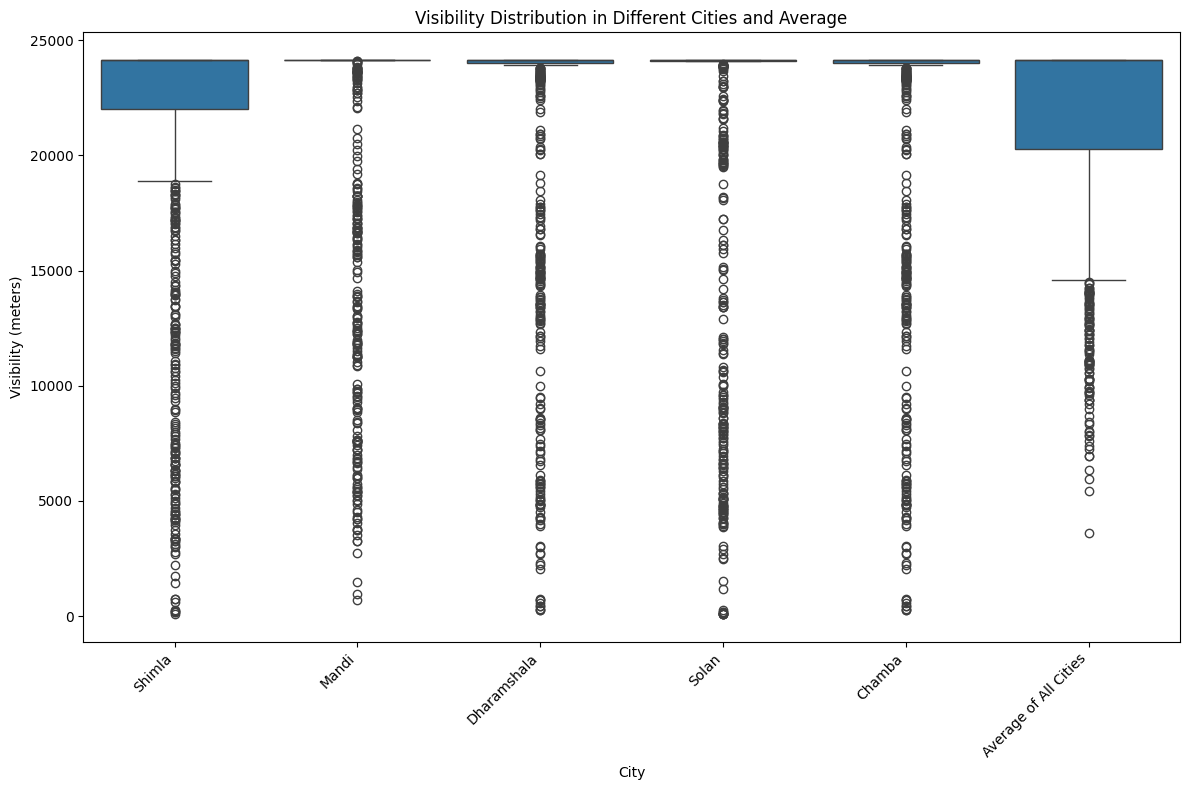

In [ ]:
# Loop through each response (city) and process the hourly data for visibility
city_visibility_dfs = []

for i, response in enumerate(responses):
    city_name = cities[i]

    hourly = response.Hourly()
    hourly_visibility = hourly.Variables(1).ValuesAsNumpy() # Get visibility data

    hourly_data = {"date": pd.date_range(
            start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
            end = pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
            freq = pd.Timedelta(seconds = hourly.Interval()),
            inclusive = "left"
    )}

    hourly_data["visibility"] = hourly_visibility
    city_visibility_df = pd.DataFrame(data = hourly_data)

    # Add city name
    city_visibility_df['city'] = city_name

    city_visibility_dfs.append(city_visibility_df)

# Concatenate all city visibility dataframes into a single dataframe
all_cities_visibility_df = pd.concat(city_visibility_dfs, ignore_index=True)

# Calculate the average visibility across all cities for each timestamp
avg_visibility = all_cities_visibility_df.groupby('date')['visibility'].mean().reset_index()
avg_visibility['city'] = 'Average of All Cities'

# Combine the average data with the city data
plot_visibility_df = pd.concat([all_cities_visibility_df, avg_visibility], ignore_index=True)

# Create the box plot for visibility
plt.figure(figsize=(12, 8))
sns.boxplot(x='city', y='visibility', data=plot_visibility_df)
plt.title('Visibility Distribution in Different Cities and Average')
plt.xlabel('City')
plt.ylabel('Visibility (meters)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

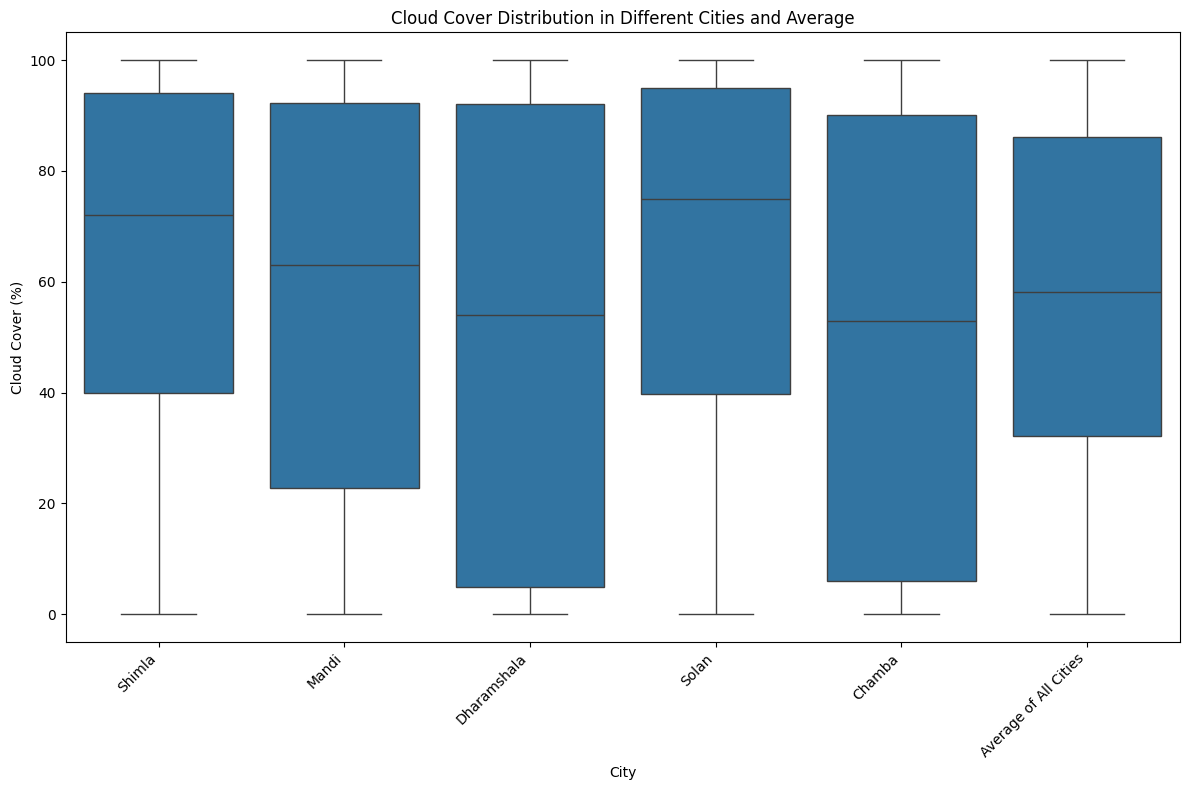

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn for boxplot

# Loop through each response (city) and process the hourly data for cloud cover
city_cloud_cover_dfs = []

for i, response in enumerate(responses):
    city_name = cities[i]

    hourly = response.Hourly()
    hourly_cloud_cover = hourly.Variables(2).ValuesAsNumpy() # Get cloud cover data

    hourly_data = {"date": pd.date_range(
            start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
            end = pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
            freq = pd.Timedelta(seconds = hourly.Interval()),
            inclusive = "left"
    )}

    hourly_data["cloud_cover"] = hourly_cloud_cover
    city_cloud_cover_df = pd.DataFrame(data = hourly_data)

    # Add city name
    city_cloud_cover_df['city'] = city_name

    city_cloud_cover_dfs.append(city_cloud_cover_df)

# Concatenate all city cloud cover dataframes into a single dataframe
all_cities_cloud_cover_df = pd.concat(city_cloud_cover_dfs, ignore_index=True)

# Calculate the average cloud cover across all cities for each timestamp
avg_cloud_cover = all_cities_cloud_cover_df.groupby('date')['cloud_cover'].mean().reset_index()
avg_cloud_cover['city'] = 'Average of All Cities'

# Combine the average data with the city data
plot_cloud_cover_df = pd.concat([all_cities_cloud_cover_df, avg_cloud_cover], ignore_index=True)

# Create the box plot for cloud cover
plt.figure(figsize=(12, 8))
sns.boxplot(x='city', y='cloud_cover', data=plot_cloud_cover_df)
plt.title('Cloud Cover Distribution in Different Cities and Average')
plt.xlabel('City')
plt.ylabel('Cloud Cover (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

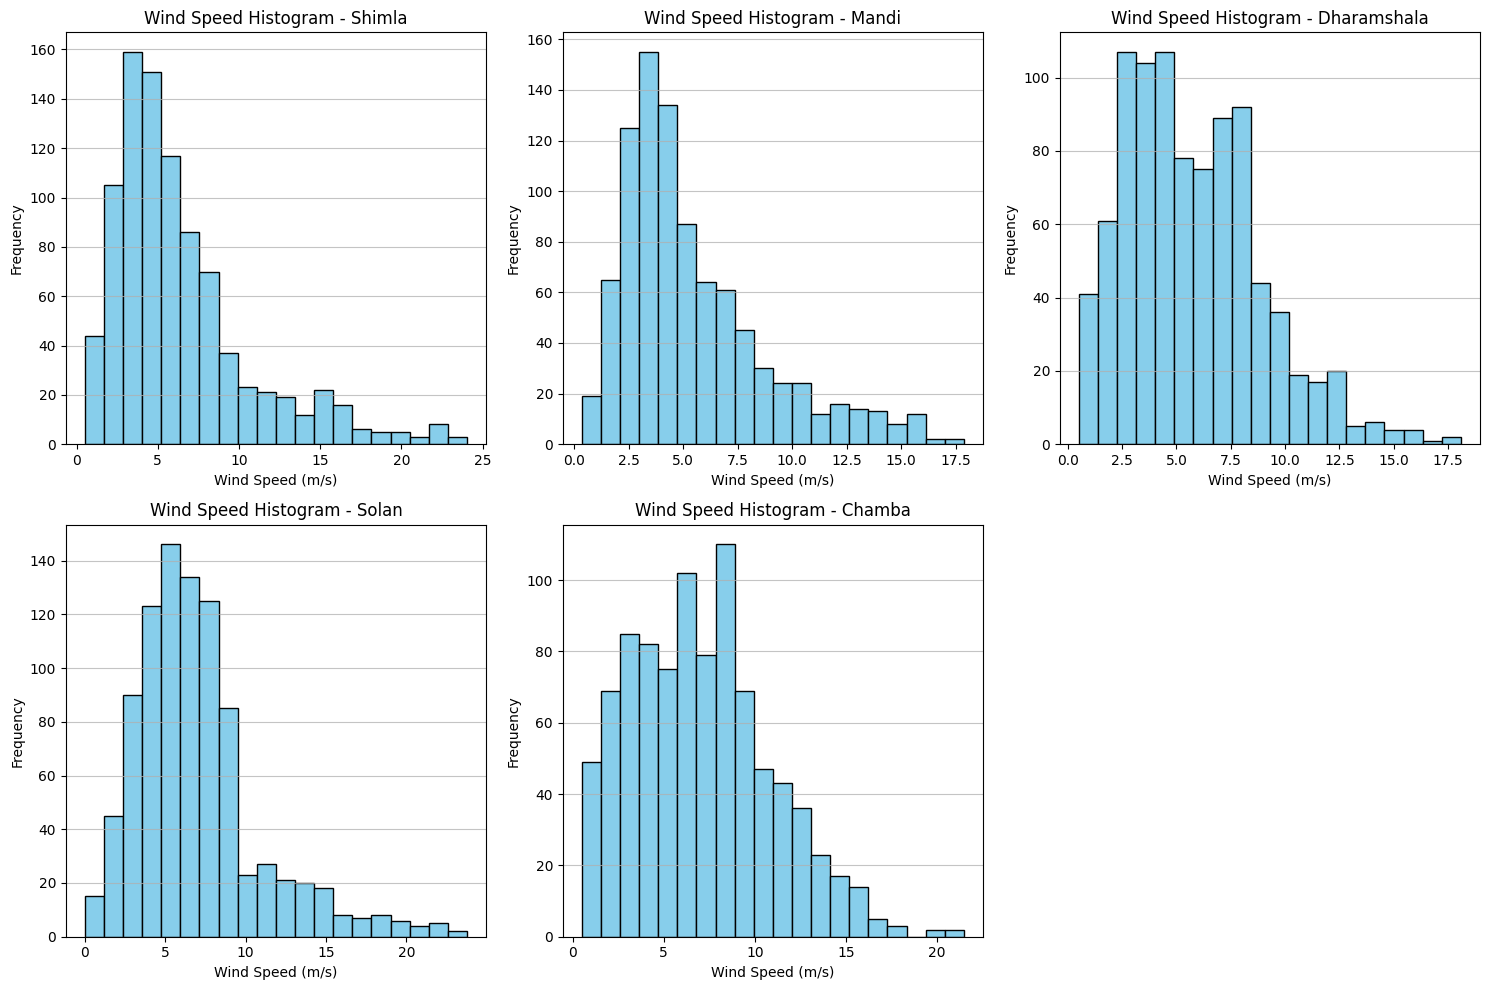

In [ ]:
import matplotlib.pyplot as plt
# Create histograms for wind speed for each city
plt.figure(figsize=(15, 10))

for i, city_name in enumerate(cities):
    plt.subplot(2, 3, i + 1) # Create a subplot for each city
    city_data = all_cities_df[all_cities_df['city'] == city_name]['wind_speed']
    plt.hist(city_data, bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Wind Speed Histogram - {city_name}')
    plt.xlabel('Wind Speed (m/s)')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)

plt.tight_layout() # Adjust layout to prevent overlap
plt.show()

### Q4. Statistical Analysis

In [ ]:
# Combine data from all locations into a single DataFrame
all_hourly_dataframes = []

for i, response in enumerate(responses):
    print(f"Processing location {i+1}: {response.Latitude()}°N {response.Longitude()}°E")

    hourly = response.Hourly()
    hourly_wind_speed_10m = hourly.Variables(0).ValuesAsNumpy()
    hourly_visibility = hourly.Variables(1).ValuesAsNumpy()
    hourly_cloud_cover = hourly.Variables(2).ValuesAsNumpy()

    hourly_data = {
        "timestamp": pd.date_range(
            start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
            end = pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
            freq = pd.Timedelta(seconds = hourly.Interval()),
            inclusive = "left"
        ),
        "wind_speed": hourly_wind_speed_10m,
        "visibility_meters": hourly_visibility,
        "cloud_cover_percentage": hourly_cloud_cover,
        "latitude": response.Latitude(),
        "longitude": response.Longitude()
    }

    location_df = pd.DataFrame(data = hourly_data)
    all_hourly_dataframes.append(location_df)

# Concatenate all dataframes
combined_df = pd.concat(all_hourly_dataframes, ignore_index=True)

# Data Cleaning and Wrangling for the combined dataframe
print("Missing values before handling in combined DataFrame:")
print(combined_df.isnull().sum())

Processing location 1: 31.0°N 77.25°E
Processing location 2: 31.625°N 76.75°E
Processing location 3: 32.125°N 76.5°E
Processing location 4: 30.875°N 77.125°E
Processing location 5: 32.375°N 76.0°E
Missing values before handling in combined DataFrame:
timestamp                 0
wind_speed                0
visibility_meters         0
cloud_cover_percentage    0
latitude                  0
longitude                 0
dtype: int64


In [ ]:
# Ensure timestamp is datetime and set as index
combined_df['timestamp'] = pd.to_datetime(combined_df['timestamp'], utc=True)
combined_df = combined_df.set_index('timestamp')
print(combined_df.head())
print("\nCombined DataFrame Info:")
combined_df.info()


                           wind_speed  visibility_meters  \
timestamp                                                  
2025-05-25 00:00:00+00:00    3.319036            24140.0   
2025-05-25 01:00:00+00:00    3.415260            24140.0   
2025-05-25 02:00:00+00:00    4.735060            24140.0   
2025-05-25 03:00:00+00:00    5.040000            24140.0   
2025-05-25 04:00:00+00:00    2.099143            24140.0   

                           cloud_cover_percentage  latitude  longitude  
timestamp                                                               
2025-05-25 00:00:00+00:00                   100.0      31.0      77.25  
2025-05-25 01:00:00+00:00                   100.0      31.0      77.25  
2025-05-25 02:00:00+00:00                   100.0      31.0      77.25  
2025-05-25 03:00:00+00:00                   100.0      31.0      77.25  
2025-05-25 04:00:00+00:00                   100.0      31.0      77.25  

Combined DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Date

In [ ]:
# Calculate descriptive statistics for the combined data across all cities
print("\nDescriptive Statistics for all cities:")
print(combined_df[['wind_speed', 'visibility_meters', 'cloud_cover_percentage']].describe())

# Calculate correlation matrix for the combined data
print("\nCorrelation Matrix for all cities:")
print(combined_df[['wind_speed', 'visibility_meters', 'cloud_cover_percentage']].corr())


Descriptive Statistics for all cities:
        wind_speed  visibility_meters  cloud_cover_percentage
count  4560.000000        4560.000000             4560.000000
mean      6.325506       21486.263672               57.070175
std       3.795890        5750.313965               37.193825
min       0.000000          80.000000                0.000000
25%       3.590954       23715.000000               23.000000
50%       5.611833       24140.000000               66.000000
75%       8.149844       24140.000000               93.000000
max      24.033876       24140.000000              100.000000

Correlation Matrix for all cities:
                        wind_speed  visibility_meters  cloud_cover_percentage
wind_speed                1.000000           0.173451               -0.207232
visibility_meters         0.173451           1.000000               -0.382824
cloud_cover_percentage   -0.207232          -0.382824                1.000000


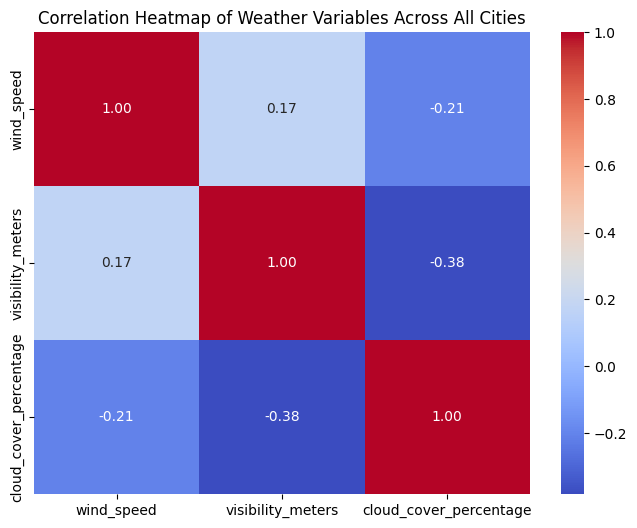

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = combined_df[['wind_speed', 'visibility_meters', 'cloud_cover_percentage']].corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Weather Variables Across All Cities')
plt.show()


--- Analysis for City at Latitude: 30.875, Longitude: 77.125 ---

Descriptive Statistics:
       wind_speed  visibility_meters  cloud_cover_percentage
count  912.000000         912.000000              912.000000
mean     6.962925       21312.718750               64.040573
std      3.943369        6166.069824               34.936134
min      0.000000          80.000000                0.000000
25%      4.379589       24080.000000               39.750000
50%      6.193674       24140.000000               75.000000
75%      8.404284       24140.000000               95.000000
max     23.773632       24140.000000              100.000000

Correlation Matrix:
                        wind_speed  visibility_meters  cloud_cover_percentage
wind_speed                 1.00000           0.214930               -0.154640
visibility_meters          0.21493           1.000000               -0.343746
cloud_cover_percentage    -0.15464          -0.343746                1.000000


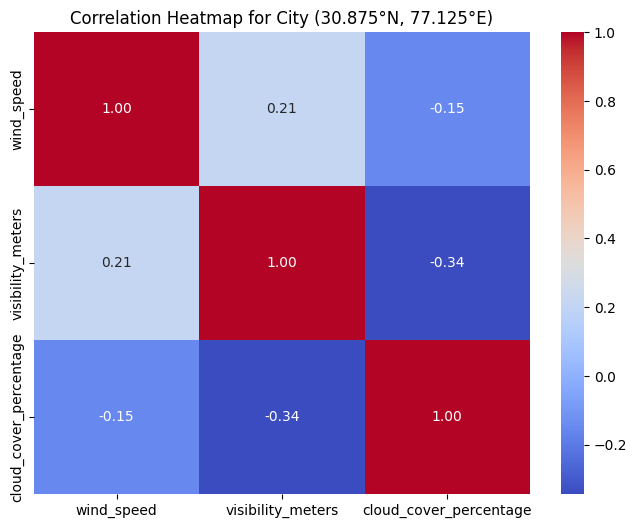


--- Analysis for City at Latitude: 31.0, Longitude: 77.25 ---

Descriptive Statistics:
       wind_speed  visibility_meters  cloud_cover_percentage
count  912.000000         912.000000              912.000000
mean     6.402434       21056.359375               63.645832
std      4.348992        6102.216797               33.821186
min      0.509117         100.000000                0.000000
25%      3.415260       22015.000000               40.000000
50%      5.154416       24140.000000               72.000000
75%      7.771331       24140.000000               94.000000
max     24.033876       24140.000000              100.000000

Correlation Matrix:
                        wind_speed  visibility_meters  cloud_cover_percentage
wind_speed                1.000000           0.012742                0.009743
visibility_meters         0.012742           1.000000               -0.362798
cloud_cover_percentage    0.009743          -0.362798                1.000000


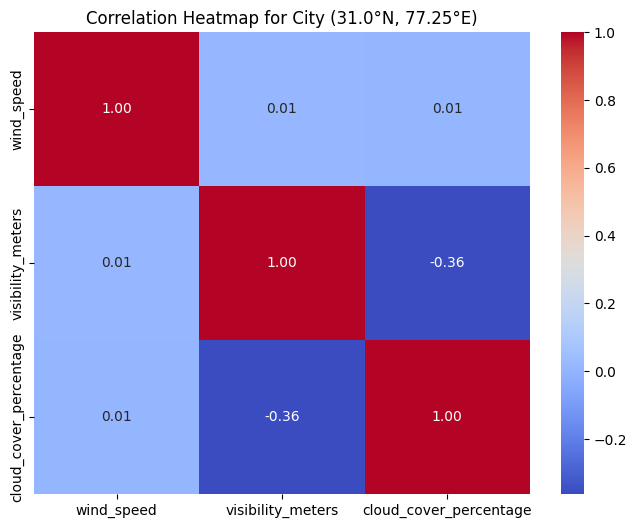


--- Analysis for City at Latitude: 31.625, Longitude: 76.75 ---

Descriptive Statistics:
       wind_speed  visibility_meters  cloud_cover_percentage
count  912.000000         912.000000              912.000000
mean     5.475790       21642.412109               55.902412
std      3.361784        5404.387207               37.020775
min      0.360000         700.000000                0.000000
25%      3.096837       24140.000000               22.750000
50%      4.510787       24140.000000               63.000000
75%      7.107141       24140.000000               92.250000
max     17.877180       24140.000000              100.000000

Correlation Matrix:
                        wind_speed  visibility_meters  cloud_cover_percentage
wind_speed                1.000000           0.167557               -0.223988
visibility_meters         0.167557           1.000000               -0.411472
cloud_cover_percentage   -0.223988          -0.411472                1.000000


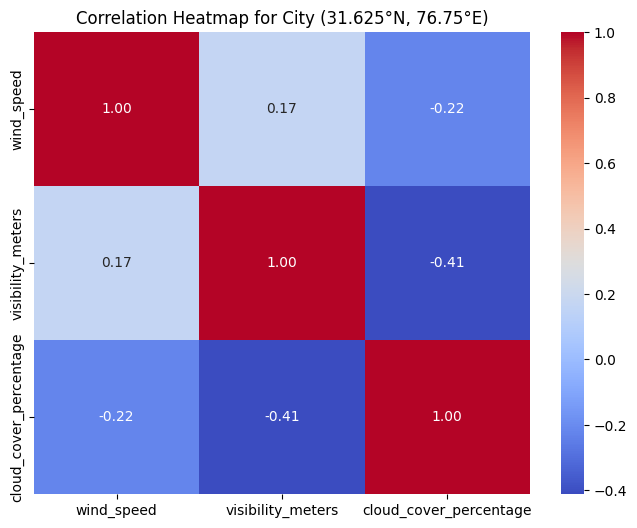


--- Analysis for City at Latitude: 32.125, Longitude: 76.5 ---

Descriptive Statistics:
       wind_speed  visibility_meters  cloud_cover_percentage
count  912.000000         912.000000              912.000000
mean     5.744965       21709.912109               51.268639
std      3.126196        5507.861816               39.146999
min      0.509117         280.000000                0.000000
25%      3.319036       24010.000000                5.000000
50%      5.351785       24140.000000               54.000000
75%      7.729527       24140.000000               92.000000
max     18.089775       24140.000000              100.000000

Correlation Matrix:
                        wind_speed  visibility_meters  cloud_cover_percentage
wind_speed                1.000000           0.241092               -0.410065
visibility_meters         0.241092           1.000000               -0.395618
cloud_cover_percentage   -0.410065          -0.395618                1.000000


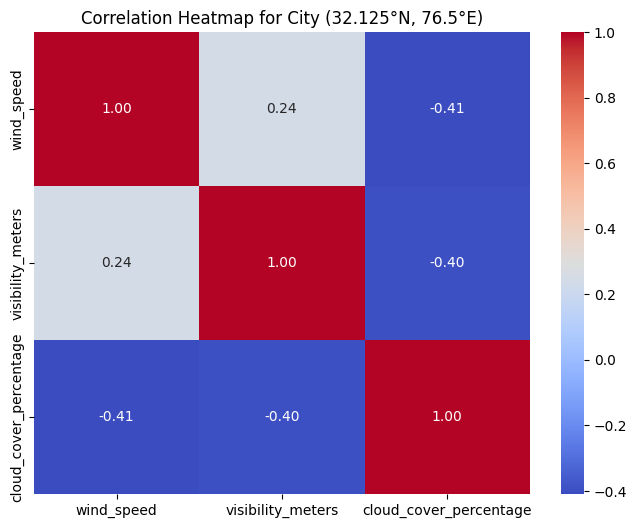


--- Analysis for City at Latitude: 32.375, Longitude: 76.0 ---

Descriptive Statistics:
       wind_speed  visibility_meters  cloud_cover_percentage
count  912.000000         912.000000              912.000000
mean     7.041418       21709.912109               50.493420
std      3.818695        5507.861816               38.538761
min      0.509117         280.000000                0.000000
25%      4.024922       24010.000000                6.000000
50%      6.638072       24140.000000               53.000000
75%      9.178235       24140.000000               90.000000
max     21.479666       24140.000000              100.000000

Correlation Matrix:
                        wind_speed  visibility_meters  cloud_cover_percentage
wind_speed                1.000000           0.305875               -0.360752
visibility_meters         0.305875           1.000000               -0.406089
cloud_cover_percentage   -0.360752          -0.406089                1.000000


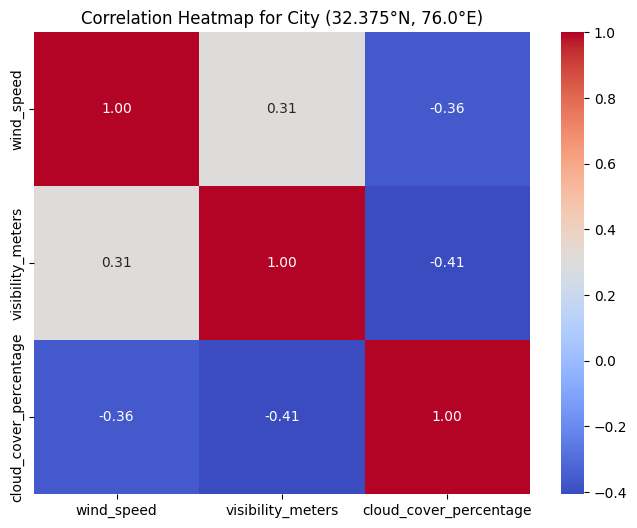

In [ ]:
import matplotlib.pyplot as plt
# Perform statistical analysis and correlation for each city individually

city_data = combined_df.groupby(['latitude', 'longitude'])

for (lat, lon), city_df in city_data:
    print(f"\n--- Analysis for City at Latitude: {lat}, Longitude: {lon} ---")

    # Descriptive Statistics for the current city
    print("\nDescriptive Statistics:")
    print(city_df[['wind_speed', 'visibility_meters', 'cloud_cover_percentage']].describe())

    # Correlation Matrix for the current city
    print("\nCorrelation Matrix:")
    city_correlation_matrix = city_df[['wind_speed', 'visibility_meters', 'cloud_cover_percentage']].corr()
    print(city_correlation_matrix)

    # Plot correlation heatmap for the current city
    plt.figure(figsize=(8, 6))
    sns.heatmap(city_correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title(f'Correlation Heatmap for City ({lat}°N, {lon}°E)')
    plt.show()


### Time Series Extension

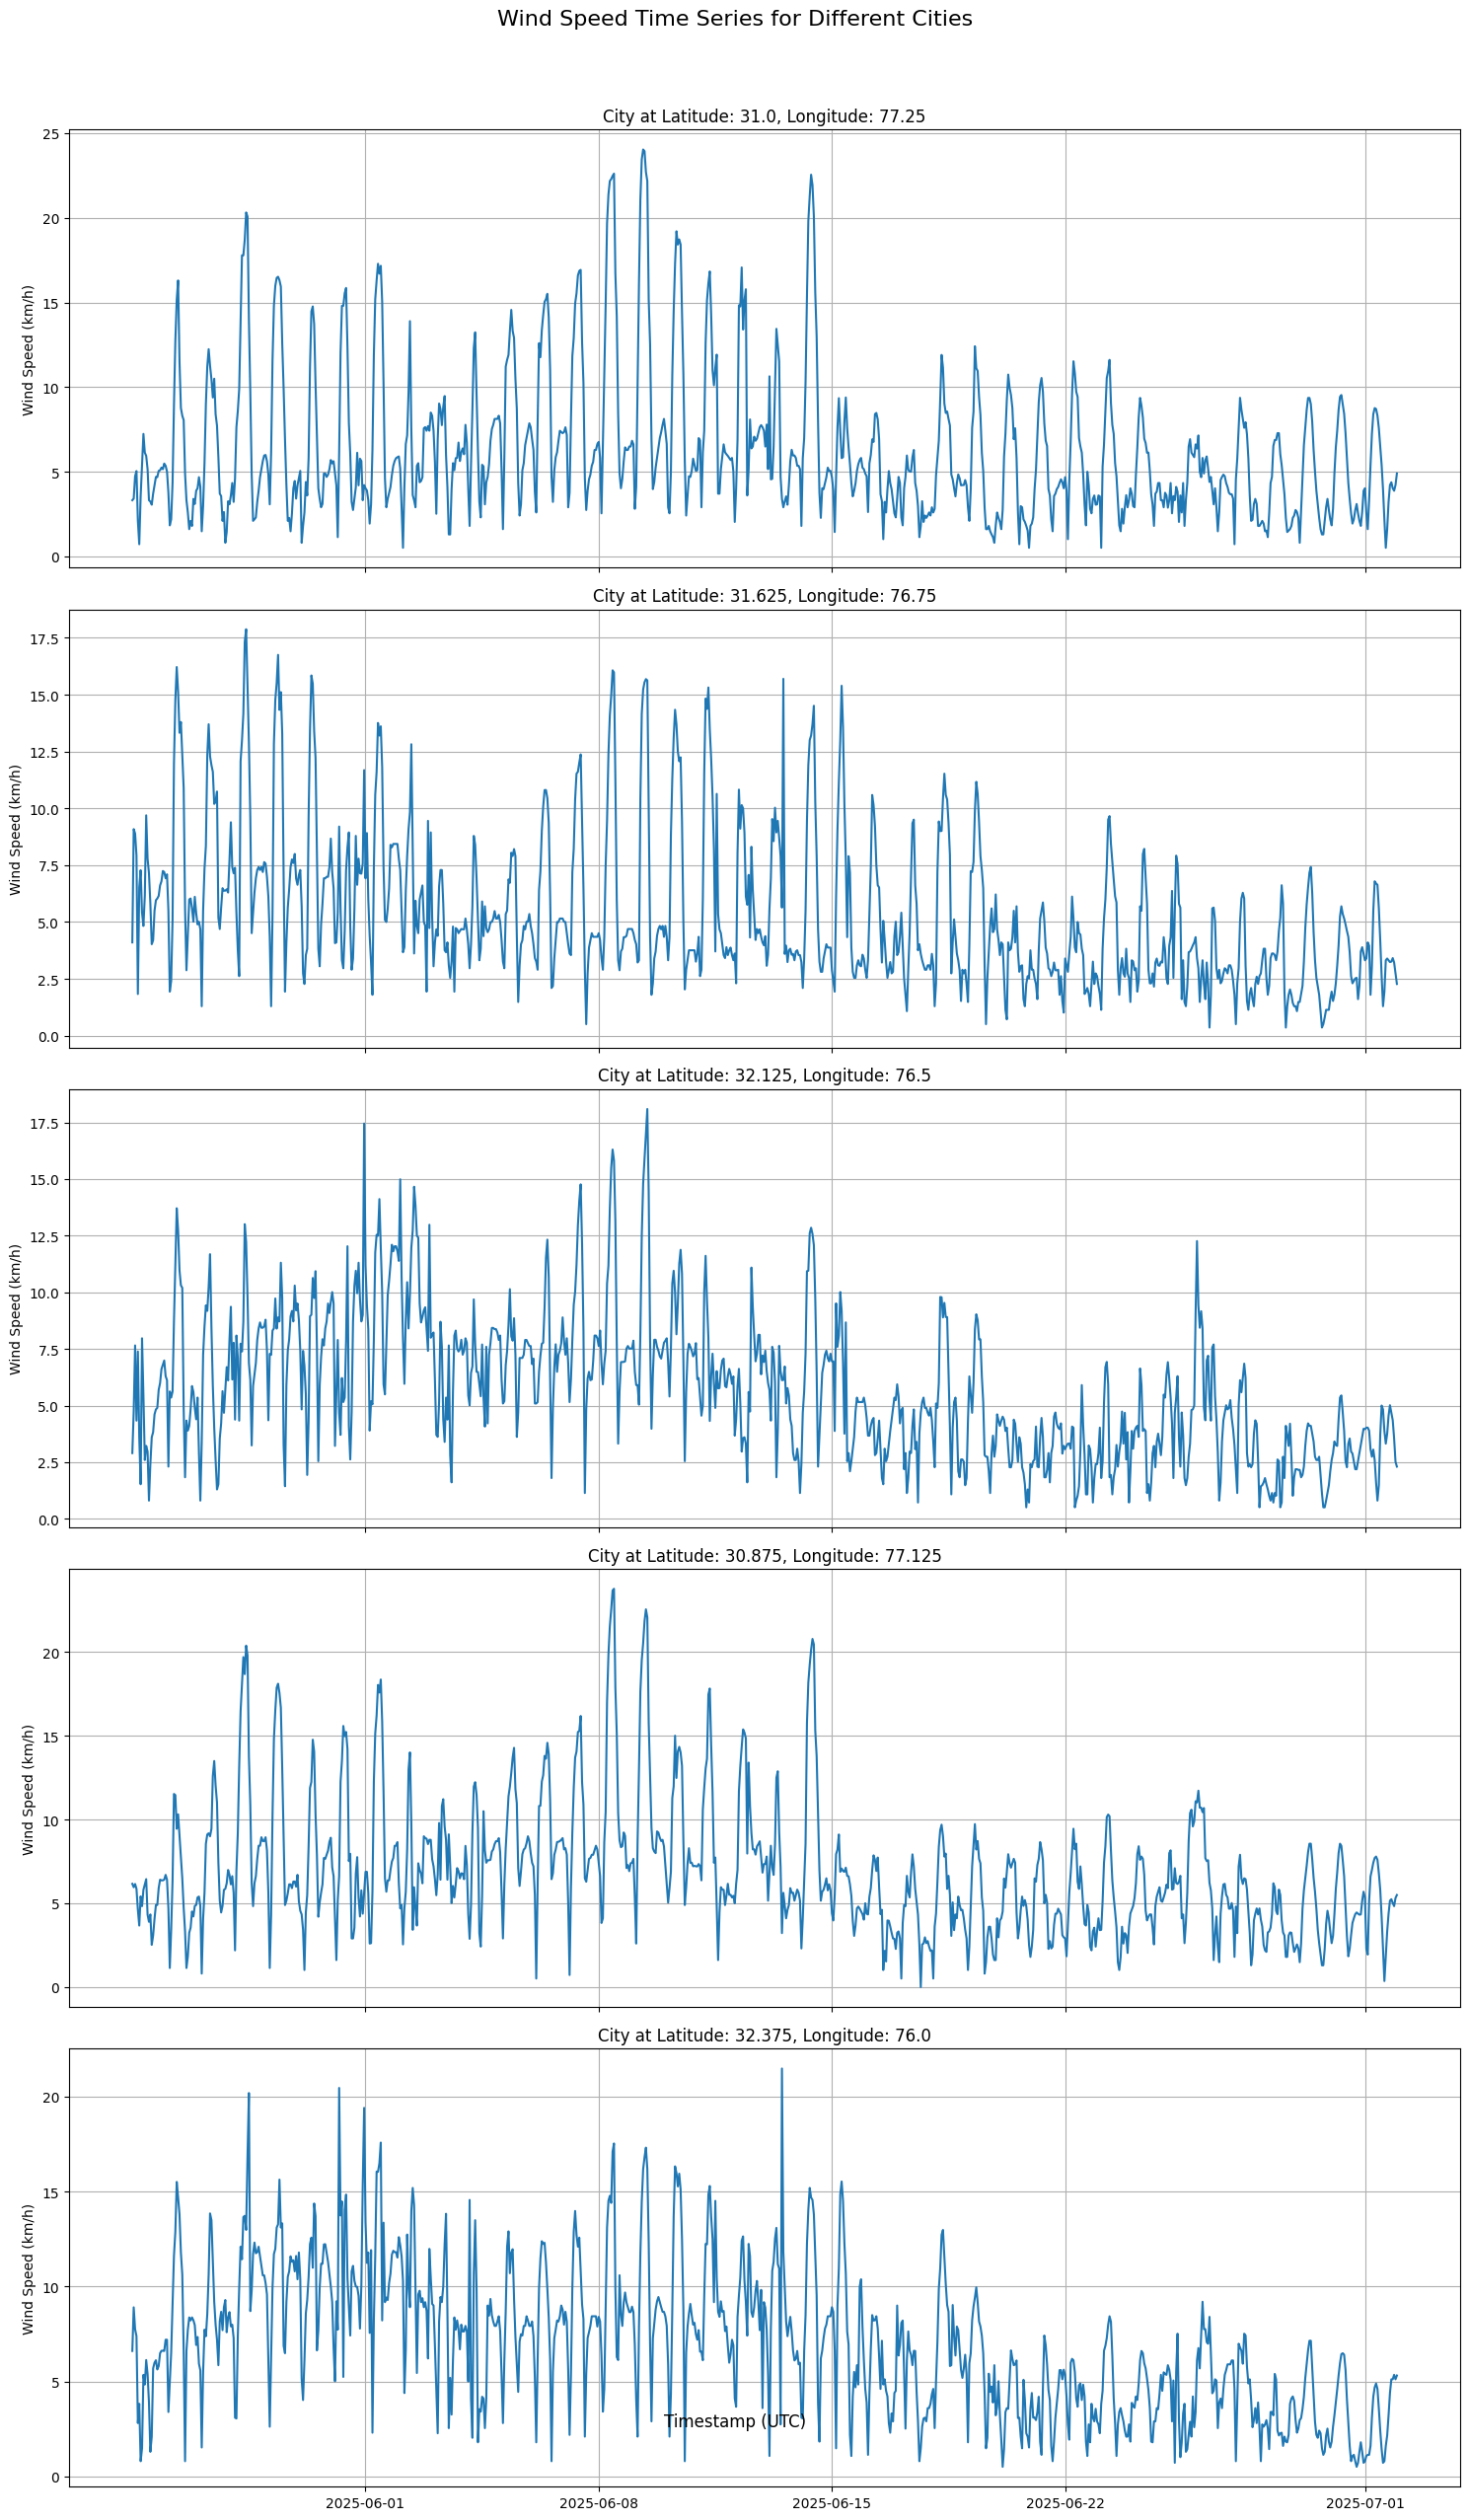

In [ ]:
locations = combined_df[['latitude', 'longitude']].drop_duplicates().values

# Create a figure and axes for the subplots
fig, axes = plt.subplots(nrows=len(locations), ncols=1, figsize=(15, 5 * len(locations)), sharex=True)
fig.suptitle('Wind Speed Time Series for Different Cities', y=1.02, fontsize=16)

for i, (lat, lon) in enumerate(locations):
    # Filter data for the current location
    city_df = combined_df[(combined_df['latitude'] == lat) & (combined_df['longitude'] == lon)]

    # Plot wind speed time series
    axes[i].plot(city_df.index, city_df['wind_speed'])
    axes[i].set_title(f'City at Latitude: {lat}, Longitude: {lon}')
    axes[i].set_ylabel('Wind Speed (km/h)')
    axes[i].grid(True)

# Set common xlabel for all subplots
fig.text(0.5, 0.04, 'Timestamp (UTC)', ha='center', fontsize=12)

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()
plt.show()

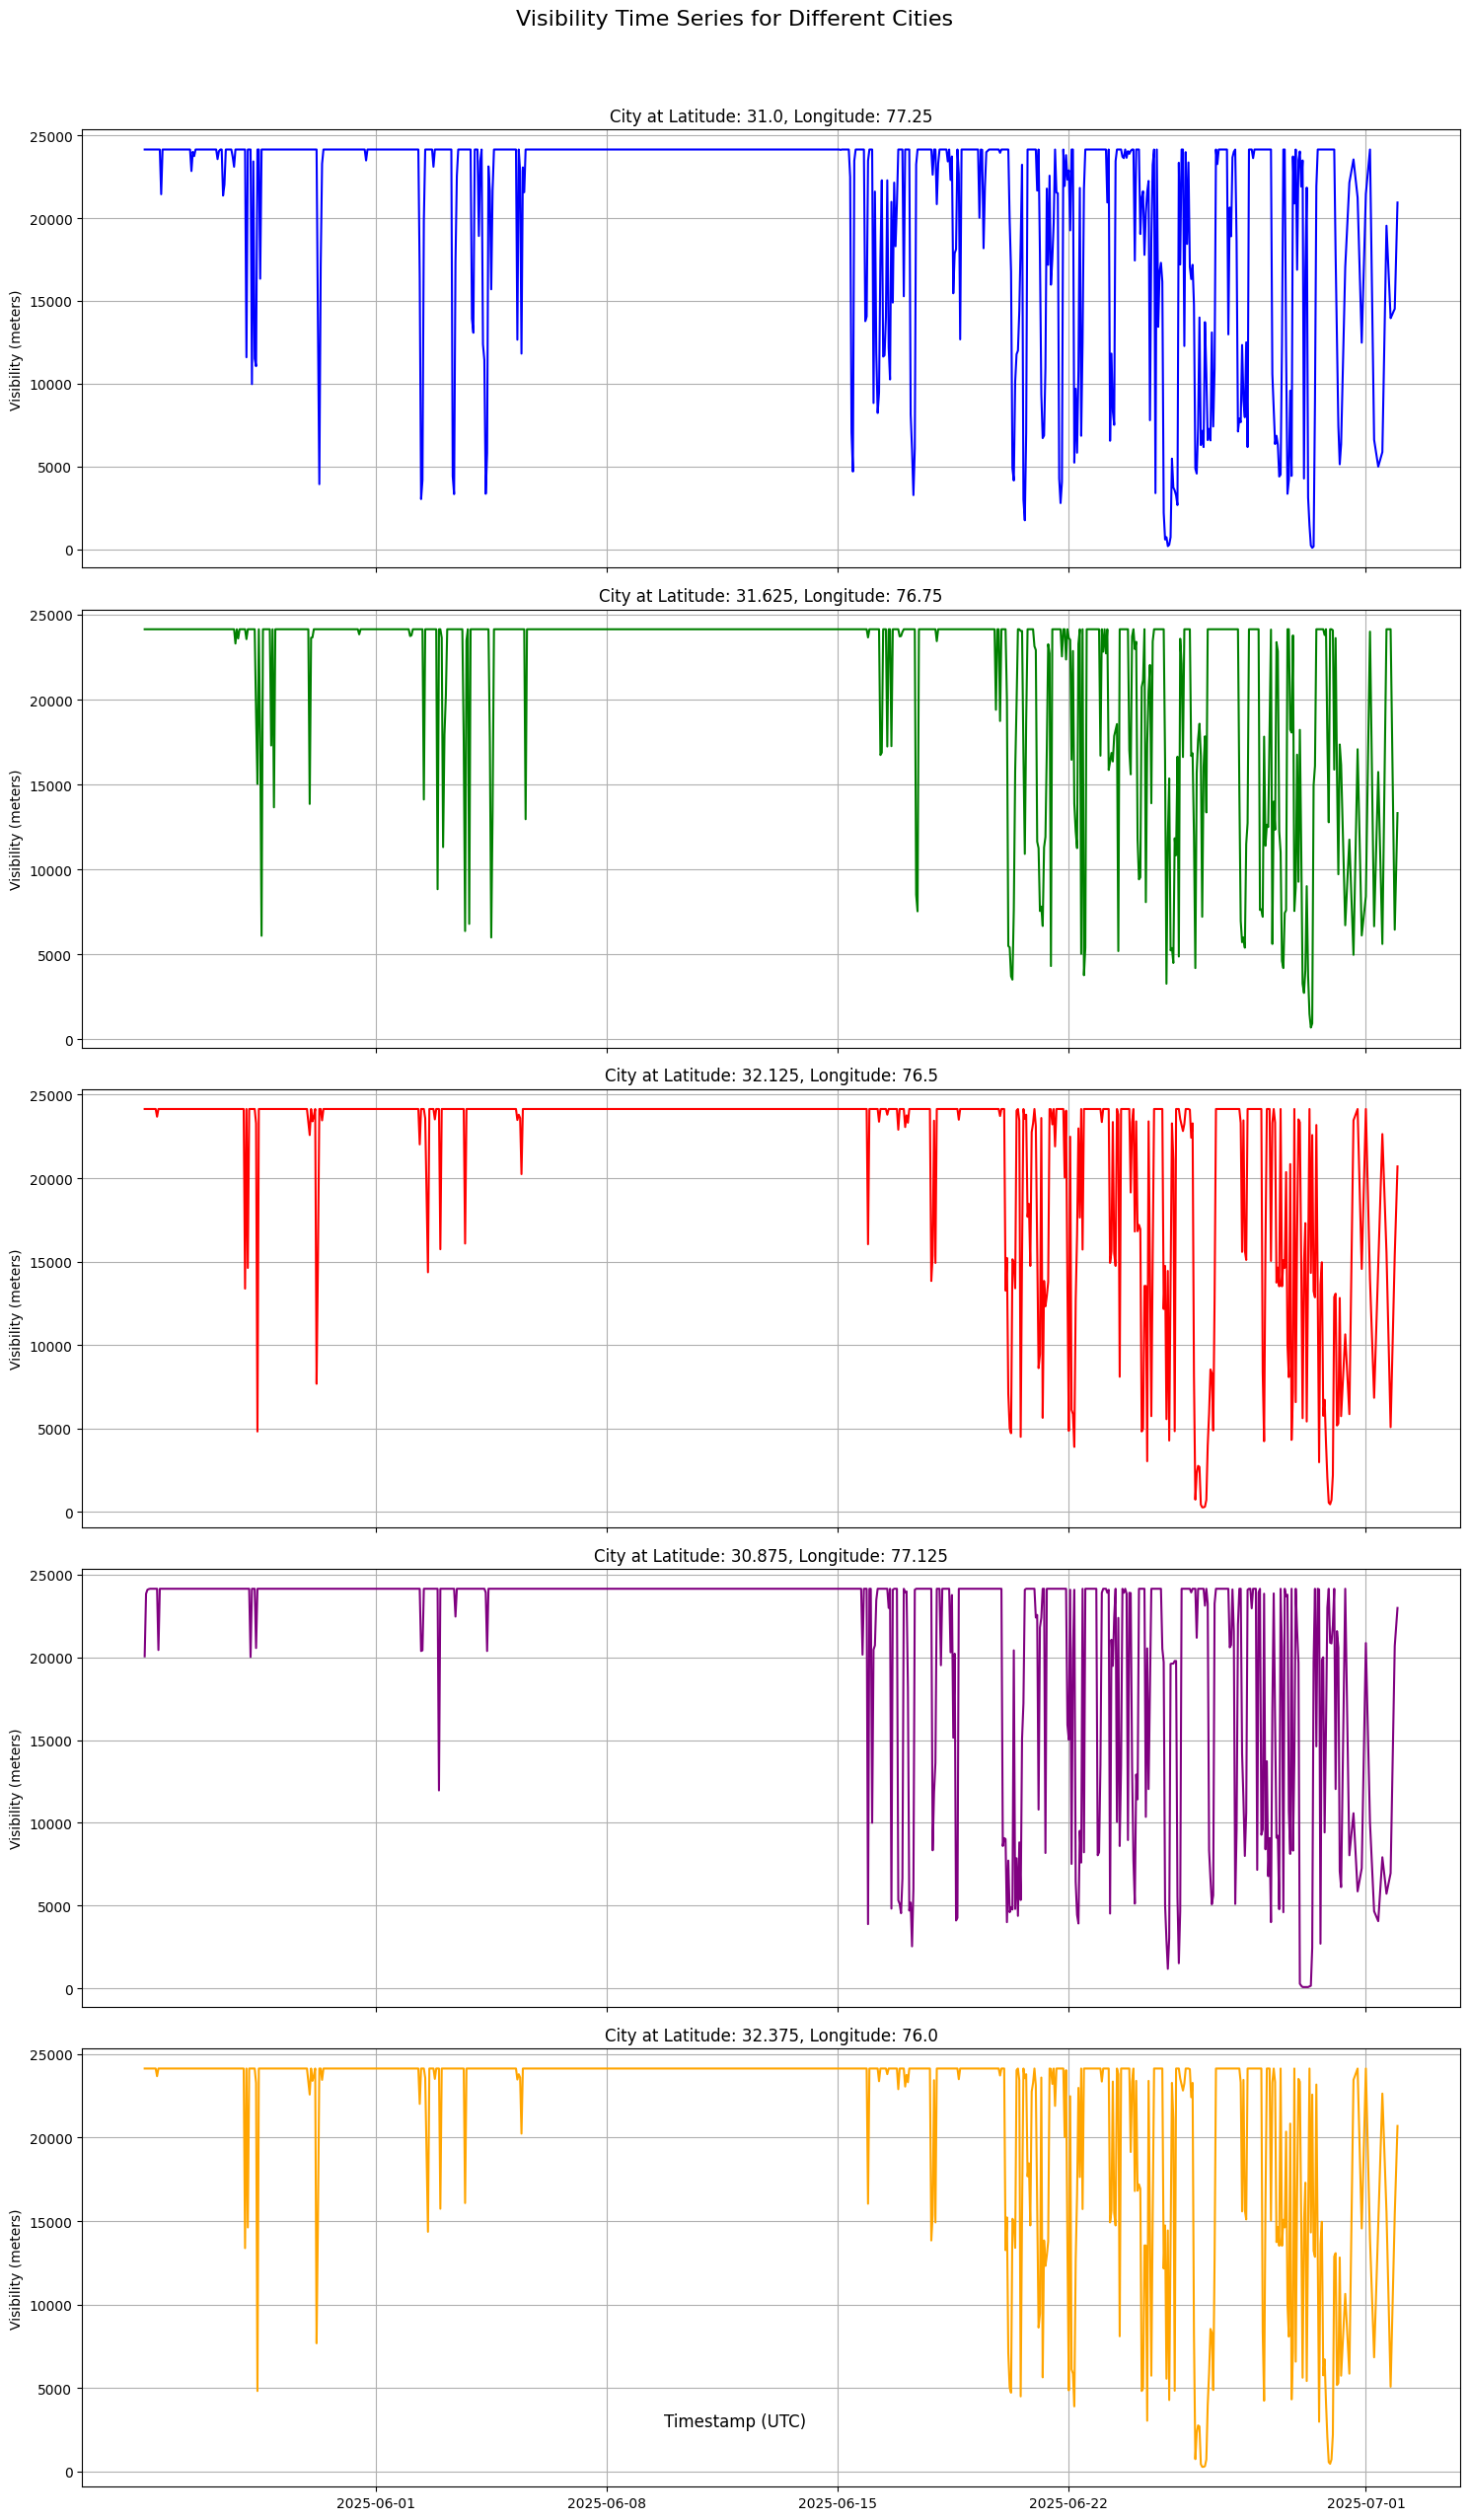

In [ ]:
# Extract unique locations (latitude, longitude pairs)
locations = combined_df[['latitude', 'longitude']].drop_duplicates().values

# Define a list of distinct colors for the plots
colors = ['blue', 'green', 'red', 'purple', 'orange']

# Create a figure and axes for the subplots
fig, axes = plt.subplots(nrows=len(locations), ncols=1, figsize=(15, 5 * len(locations)), sharex=True)
fig.suptitle('Visibility Time Series for Different Cities', y=1.02, fontsize=16)

for i, (lat, lon) in enumerate(locations):
    # Filter data for the current location
    city_df = combined_df[(combined_df['latitude'] == lat) & (combined_df['longitude'] == lon)]

    # Plot visibility time series using a different color for each city
    axes[i].plot(city_df.index, city_df['visibility_meters'], color=colors[i % len(colors)]) # Use modulo to cycle through colors
    axes[i].set_title(f'City at Latitude: {lat}, Longitude: {lon}')
    axes[i].set_ylabel('Visibility (meters)')
    axes[i].grid(True)

# Set common xlabel for all subplots
fig.text(0.5, 0.04, 'Timestamp (UTC)', ha='center', fontsize=12)

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()
plt.show()

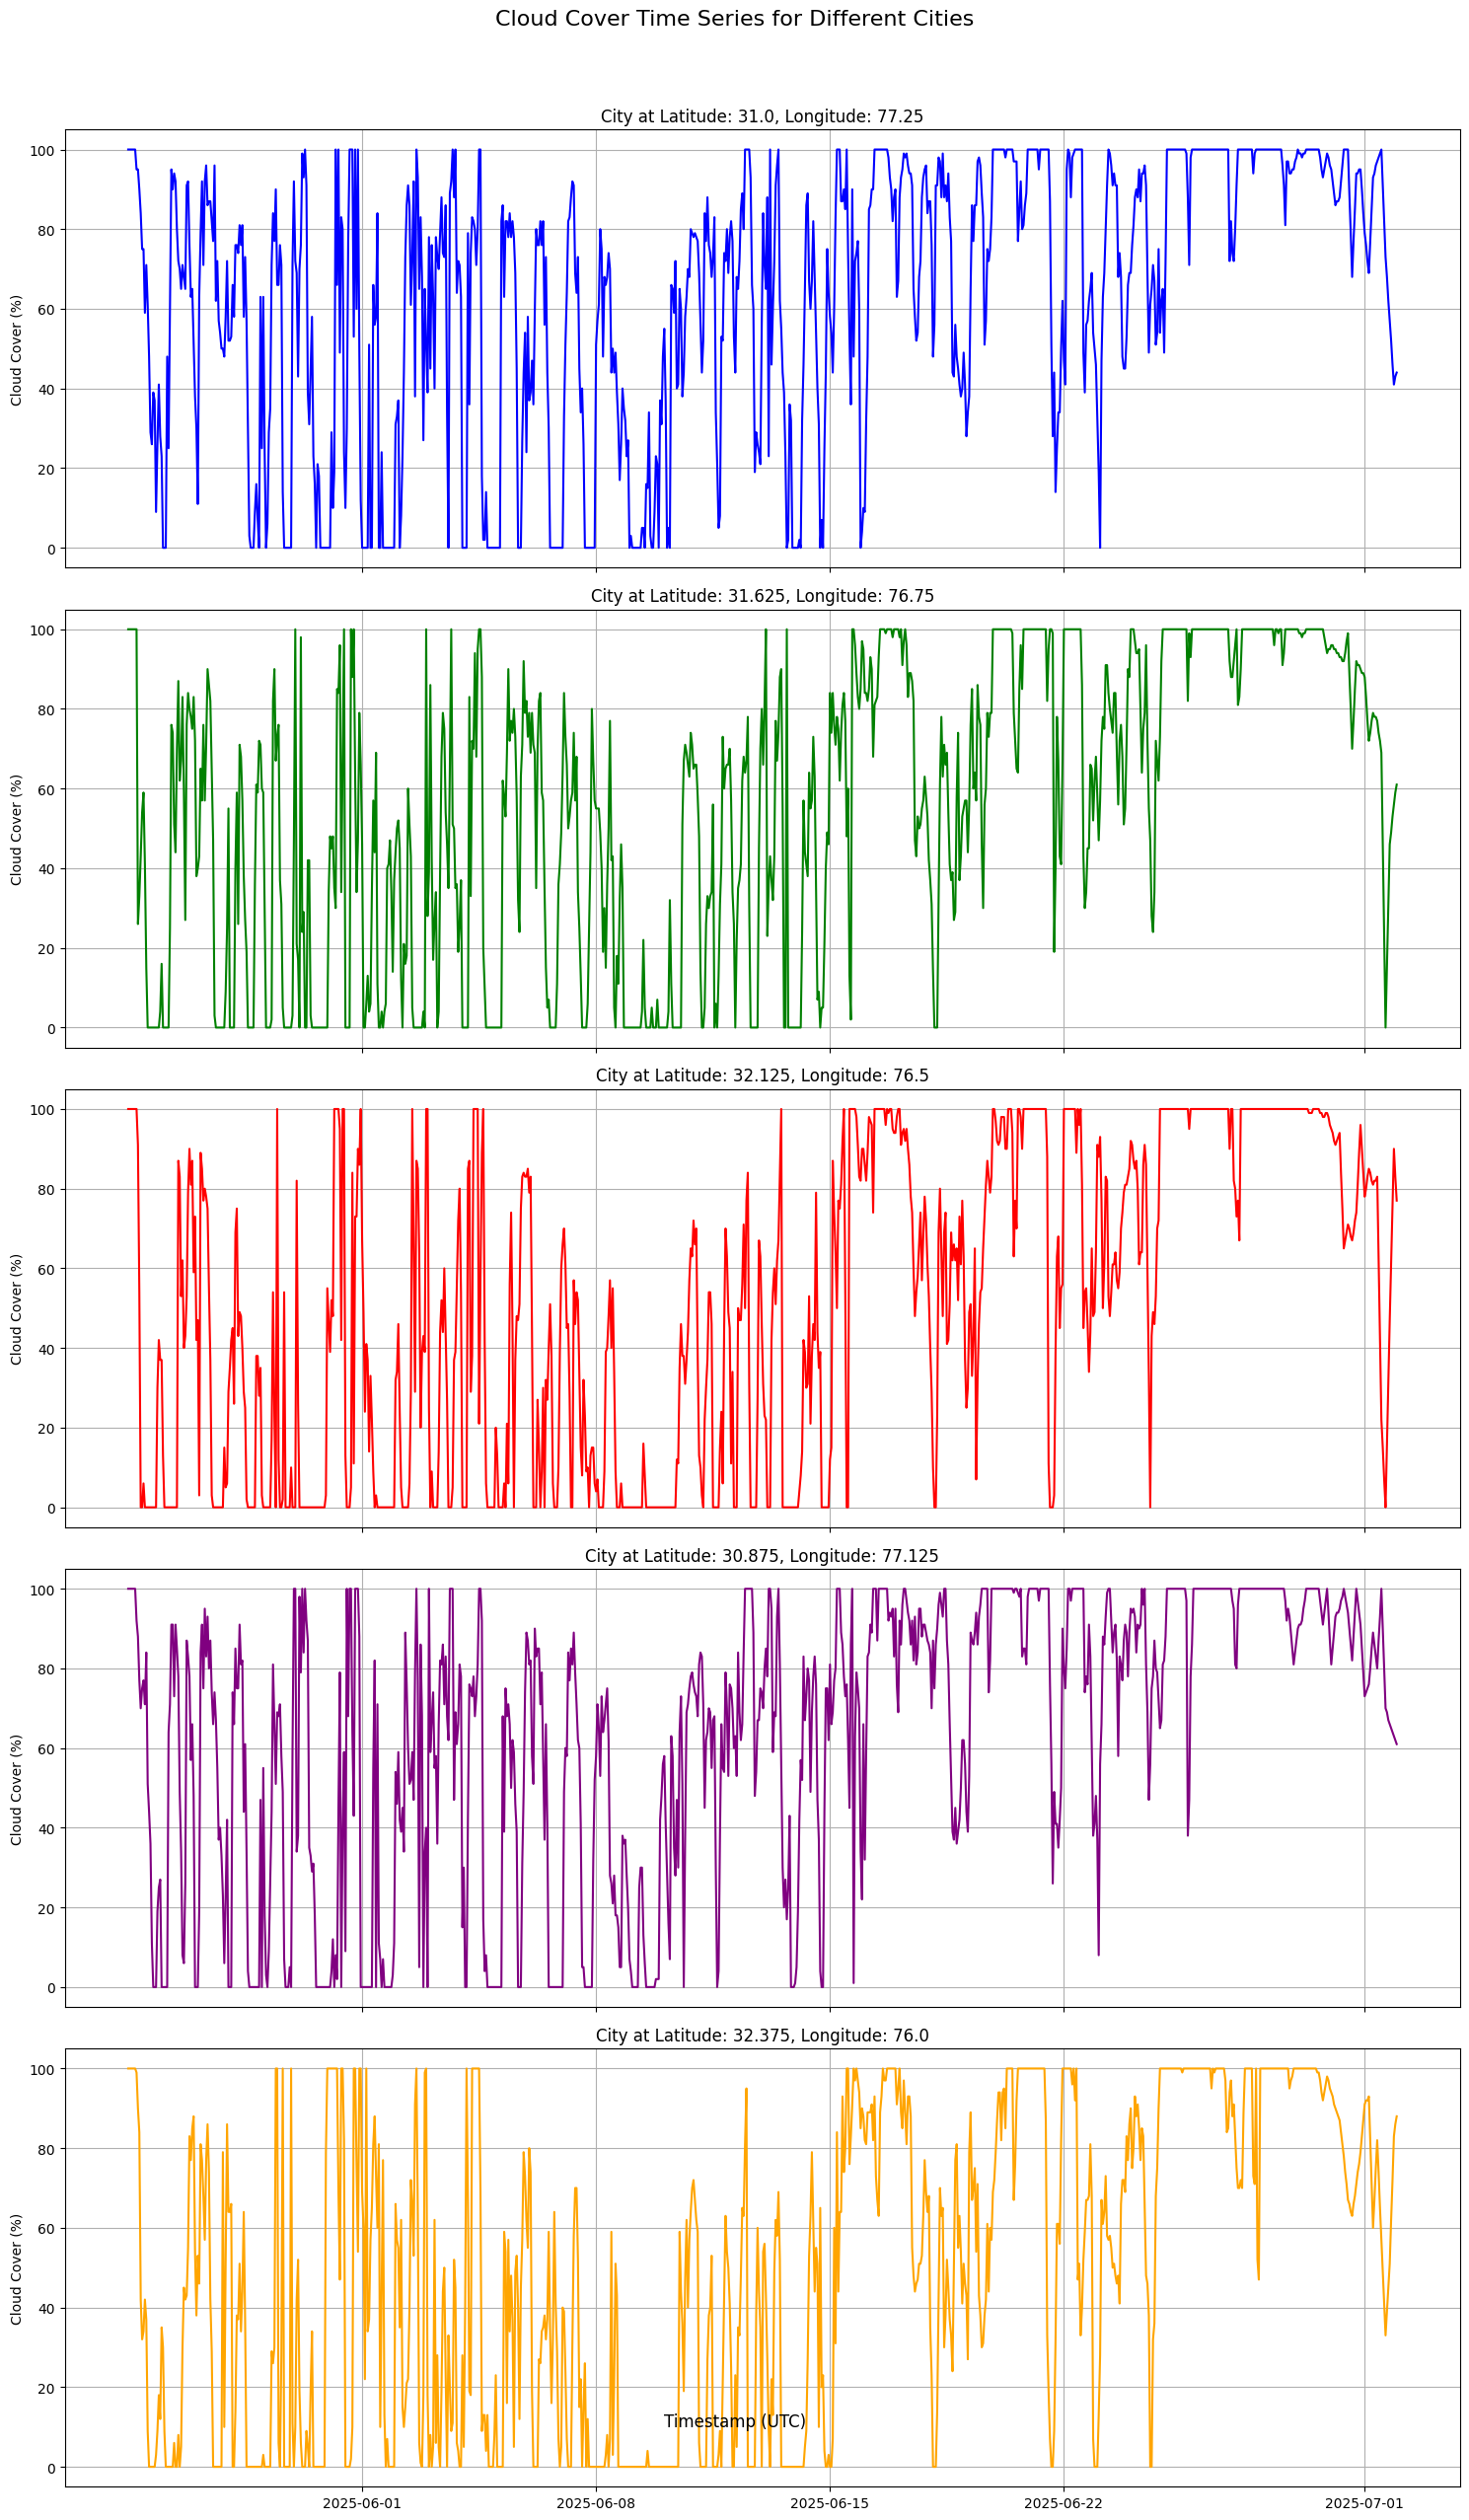

In [ ]:
# Create a figure and axes for the subplots
fig, axes = plt.subplots(nrows=len(locations), ncols=1, figsize=(15, 5 * len(locations)), sharex=True)
fig.suptitle('Cloud Cover Time Series for Different Cities', y=1.02, fontsize=16)

for i, (lat, lon) in enumerate(locations):
    # Filter data for the current location
    city_df = combined_df[(combined_df['latitude'] == lat) & (combined_df['longitude'] == lon)]

    # Plot cloud cover time series using a different color for each city
    axes[i].plot(city_df.index, city_df['cloud_cover_percentage'], color=colors[i % len(colors)]) # Use modulo to cycle through colors
    axes[i].set_title(f'City at Latitude: {lat}, Longitude: {lon}')
    axes[i].set_ylabel('Cloud Cover (%)')
    axes[i].grid(True)

# Set common xlabel for all subplots
fig.text(0.5, 0.04, 'Timestamp (UTC)', ha='center', fontsize=12)

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()
plt.show()